# Christmas Gift Price Prediction — Project Overview

##  Context
Online retailers use promotions and special offers to attract new visitors, increase traffic, and boost sales. Understanding product characteristics and customer behavior helps improve these strategies.
This project begins with **unsupervised learning** to explore the structure of the data before predicting prices.

##  Dataset Description
The dataset contains different types of information related to gifts:

- **gift_id** — Unique identifier
- **gift_type** — Type of gift (ex: clothes, perfumes…)
- **gift_category** — Category within the gift type
- **gift_cluster** — Industry or group the gift belongs to
- **instock_date** — Date when the product arrived in stock
- **stock_update_date** — Last stock update date
- **lsg_1 to lsg_6** — Anonymized numerical features
- **uk_date1, uk_date2** — Buyer-related dates
- **is_discounted_**


## Partie A


In [1]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scipy

  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl (11.0 MB)
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
    --------------------------------------- 0.3/12.8 MB ? eta -:--:--
   --- ------------------------------------ 1.0/12.8 MB 3.3 MB/s eta 0:00:04
   ---- ----------------------------------- 1.6/12.8 MB 2.9 MB/s eta 0:00:04
   ----- ---------------------------------- 1.8/12.8 MB 2.8 MB/s eta 0:00:04
   ------ --------------------------------- 2.1/12.8 MB 2.1 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.8 MB 2.1 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.8 MB 2.1 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.8 MB 2.1 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.8 MB 2.1 MB/s eta 0:00:06
   ------ --------------------------------- 2.


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp313-cp313-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.60.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl (73 kB)
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/7.0 MB ? eta -:--:--
   ---- ----------------------------------- 0.8/


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.5 MB ? eta -:--:--
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    --------------------------------------- 0.5/38.5 MB 1.5 MB/s eta 0:00:26
    ---------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## Phase 1 — Data Exploration
In this first step, we will explore our dataset before any preprocessing or clustering

In [3]:
# import librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



#### Step 1 — Loading the dataset
We load the CSV file and display the first lines to check its structure.

In [4]:
df = pd.read_csv("train..csv")
df.head()

,gift_id,gift_type,gift_category,gift_cluster,instock_date,stock_update_date,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,uk_date1,uk_date2,is_discounted,volumes,price
0,GF_11156,61,534,3942,2014-02-21 05:07:06.000,2016-11-09 15:49:51.000,3377,5221,504,1912,10,554,2014-02-24 08:07:06.000,2014-02-24 07:07:06.000,0,NaN,175.54
1,GF_11157,61,534,3942,2014-02-21 06:07:06.000,2016-11-11 13:49:51.000,3377,5221,504,1912,10,554,2014-02-22 07:07:06.000,2014-02-24 06:07:06.000,1,NaN,95.80
2,GF_15689,584,262,0,2014-02-21 09:30:21.000,2016-03-24 14:46:18.000,5290,1579,3203,1912,9,1578,2016-01-26 00:04:45.000,2016-03-18 02:00:00.000,1,NaN,107.35
3,GF_11155,61,534,3942,2014-02-22 05:07:06.000,2016-11-10 16:49:51.000,3377,5221,504,1912,10,554,2016-11-07 13:49:51.000,2016-11-06 04:00:00.000,0,NaN,172.90
4,GF_11158,61,534,3942,2014-02-22 07:07:06.000,2016-11-10 13:49:51.000,3377,5221,504,1912,9,554,2016-11-07 15:49:51.000,2016-11-06 01:00:00.000,1,NaN,77.72


#### Step 2 - General information
We display the types of columns and the structure of the dataset.

In [12]:
print(" Dataset information:")
df.info()
df.describe()

 Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20279 entries, 0 to 20278
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gift_id            20279 non-null  object 
 1   gift_type          20279 non-null  int64  
 2   gift_category      20279 non-null  int64  
 3   gift_cluster       20279 non-null  int64  
 4   instock_date       20279 non-null  object 
 5   stock_update_date  20279 non-null  object 
 6   lsg_1              20279 non-null  int64  
 7   lsg_2              20279 non-null  int64  
 8   lsg_3              20279 non-null  int64  
 9   lsg_4              20279 non-null  int64  
 10  lsg_5              20279 non-null  int64  
 11  lsg_6              20279 non-null  int64  
 12  uk_date1           20279 non-null  object 
 13  uk_date2           20279 non-null  object 
 14  is_discounted      20279 non-null  int64  
 15  volumes            7323 non-null   float64
 16  

,gift_type,gift_category,gift_cluster,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,is_discounted,volumes,price
count,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,7323.000000,20279.000000
mean,739.554662,394.171557,3303.358548,5314.595345,4187.653928,4866.945510,1679.152226,8.652695,1265.898171,0.229646,15.515363,143.404411
std,389.216989,235.077769,2541.082549,2703.317282,2274.875522,2713.856392,485.699119,2.349388,697.838495,0.420616,7.579669,267.281159
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,5.000000,0.010000
25%,403.000000,188.000000,587.000000,3311.000000,2251.000000,2548.000000,1801.000000,9.000000,577.500000,0.000000,9.000000,45.645000
50%,825.000000,433.000000,3231.000000,5520.000000,4246.000000,4839.000000,1912.000000,9.000000,1616.000000,0.000000,13.000000,75.600000
75%,1032.000000,534.000000,5787.000000,7535.000000,6504.500000,7387.000000,1912.000000,10.000000,1899.000000,0.000000,24.000000,126.845000
max,1360.000000,893.000000,7567.000000,9979.000000,7604.000000,9493.000000,2056.000000,10.000000,2065.000000,1.000000,29.000000,7010.270000


#### Step 3 - Missing value

In [13]:
df.isnull().sum()

gift_id                  0
gift_type                0
gift_category            0
gift_cluster             0
instock_date             0
stock_update_date        0
lsg_1                    0
lsg_2                    0
lsg_3                    0
lsg_4                    0
lsg_5                    0
lsg_6                    0
uk_date1                 0
uk_date2                 0
is_discounted            0
volumes              12956
price                    0
dtype: int64

here we realize that the volume lacks a lot of values, it can be related to the fact that the products are not yet sold for example. Knowing that volume is important information for us, we will do the median (because we cannot delete lines without volumes or replace them with 0)

In [14]:
df["volumes"] = df["volumes"].fillna(df["volumes"].median())


#### Step 4 - Number of rows and columns
Small overview of the dataset size.



In [17]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 20279
Number of columns: 17


#### Step 5 - List of columns
To quickly identify important variables.

In [7]:

print("Dataset columns:")
df.columns

Dataset columns:


Index(['gift_id', 'gift_type', 'gift_category', 'gift_cluster', 'instock_date',
       'stock_update_date', 'lsg_1', 'lsg_2', 'lsg_3', 'lsg_4', 'lsg_5',
       'lsg_6', 'uk_date1', 'uk_date2', 'is_discounted', 'volumes', 'price'],
      dtype='object')

#### Step 6 - Descriptive statistics
Statistical summary of numerical and categorical variables.

In [8]:
df.describe(include='all')

,gift_id,gift_type,gift_category,gift_cluster,instock_date,stock_update_date,lsg_1,lsg_2,lsg_3,lsg_4,lsg_5,lsg_6,uk_date1,uk_date2,is_discounted,volumes,price
count,20279,20279.000000,20279.000000,20279.000000,20279,20279,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279.000000,20279,20279,20279.000000,7323.000000,20279.000000
unique,20279,NaN,NaN,NaN,17147,14794,NaN,NaN,NaN,NaN,NaN,NaN,16384,7210,NaN,NaN,NaN
top,GF_11156,NaN,NaN,NaN,2015-09-22 14:30:05.000,2017-03-12 18:39:44.000,NaN,NaN,NaN,NaN,NaN,NaN,2017-03-31 12:40:24.000,2016-11-04 02:00:00.000,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,7,17,NaN,NaN,NaN,NaN,NaN,NaN,17,97,NaN,NaN,NaN
mean,NaN,739.554662,394.171557,3303.358548,NaN,NaN,5314.595345,4187.653928,4866.945510,1679.152226,8.652695,1265.898171,NaN,NaN,0.229646,15.515363,143.404411
std,NaN,389.216989,235.077769,2541.082549,NaN,NaN,2703.317282,2274.875522,2713.856392,485.699119,2.349388,697.838495,NaN,NaN,0.420616,7.579669,267.281159
min,NaN,1.000000,1.000000,0.000000,NaN,NaN,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,NaN,NaN,0.000000,5.000000,0.010000
25%,NaN,403.000000,188.000000,587.000000,NaN,NaN,3311.000000,2251.000000,2548.000000,1801.000000,9.000000,577.500000,NaN,NaN,0.000000,9.000000,45.645000
50%,NaN,825.000000,433.000000,3231.000000,NaN,NaN,5520.000000,4246.000000,4839.000000,1912.000000,9.000000,1616.000000,NaN,NaN,0.000000,13.000000,75.600000
75%,NaN,1032.000000,534.000000,5787.000000,NaN,NaN,7535.000000,6504.500000,7387.000000,1912.000000,10.000000,1899.000000,NaN,NaN,0.000000,24.000000,126.845000


##### Conclusion after describe:
The dataset contains:
* Many digital features (lsg_1 lsg_6)
* Several dates to transform
* An unnecessary ID column
* An unbalanced binary column (is_discounted)
* A very skewed price column (outliers)

2. Two mandatory actions:
* Fill in the missing values of volumes (did it in the section missing value in top)
* Remove or reduce outliers in price

#### Step 7 - Delete unnecessary columns
gift_id is a unique identifier it is not used for the ML

In [20]:
df = df.drop(["gift_id"], axis=1)


KeyError: "['gift_id'] not found in axis"

In [21]:
df.columns

Index(['gift_type', 'gift_category', 'gift_cluster', 'instock_date',
       'stock_update_date', 'lsg_1', 'lsg_2', 'lsg_3', 'lsg_4', 'lsg_5',
       'lsg_6', 'uk_date1', 'uk_date2', 'is_discounted', 'volumes', 'price'],
      dtype='object')

#### Step 8 - Check for duplicates

In [22]:
duplicates = df.duplicated().sum()
print("Number of duplicates :", duplicates)

df = df.drop_duplicates()


Nombre de doublons : 0


#### Step 9 - Convert non-numeric columns

In [24]:
#Convert dates to datetime
df["instock_date"] = pd.to_datetime(df["instock_date"])
df["stock_update_date"] = pd.to_datetime(df["stock_update_date"])
df["uk_date1"] = pd.to_datetime(df["uk_date1"])
df["uk_date2"] = pd.to_datetime(df["uk_date2"])


In [25]:
#Extract useful information --> create groups
df["instock_year"] = df["instock_date"].dt.year
df["stock_update_year"] = df["stock_update_date"].dt.year
df["uk_year1"] = df["uk_date1"].dt.year
df["uk_year2"] = df["uk_date2"].dt.year


In [26]:
#Delete the original date columns
df = df.drop(["instock_date", "stock_update_date", "uk_date1", "uk_date2"], axis=1)


#### Step 10 - Detection and processing of OUTLIERS



In [28]:
# outliers PRICE
df["price"].describe()


count    20279.000000
mean       143.404411
std        267.281159
min          0.010000
25%         45.645000
50%         75.600000
75%        126.845000
max       7010.270000
Name: price, dtype: float64

analyze: The vast majority of prices are between €45 and 130€ --> It’s totally normal for small gifts.
The max = €7010 is extremely abnormal
--> More than 50x greater than the 75th percentile

==> we will have to filter the outliers but not too much so as not to lose too much data

In [29]:
df = df[df["price"] <= 600]


In [30]:
# Outlier VOLUMES
df["volumes"].describe()

count    19363.000000
mean        13.952228
std          4.817316
min          5.000000
25%         13.000000
50%         13.000000
75%         13.000000
max         29.000000
Name: volumes, dtype: float64

min 5 and max 29 : low amplitude = No need to filter.

In [33]:
# Outliers LSG_number
df["lsg_3"].describe() # choose 3 for just look variable

count    19363.000000
mean      4888.849094
std       2723.006757
min          0.000000
25%       2567.000000
50%       4817.000000
75%       7460.000000
max       9493.000000
Name: lsg_3, dtype: float64

analyze : we had no need for a filter but the values are consistent with each other.
The min = 0 is possible depending on the direction of the variable.
The max = 9493 is consistent with the distribution (75% = 7460).
So you have no reason to apply an outliers filter here

#### Step 11 : Visualization

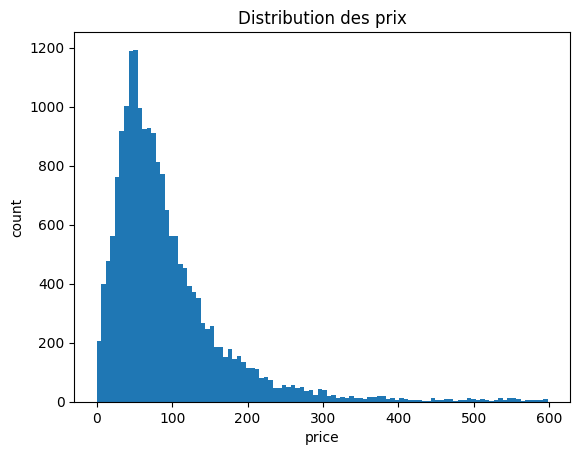

In [34]:
#Price histogram
plt.hist(df["price"], bins=100)
plt.title("Distribution des prix")
plt.xlabel("price")
plt.ylabel("count")
plt.show()


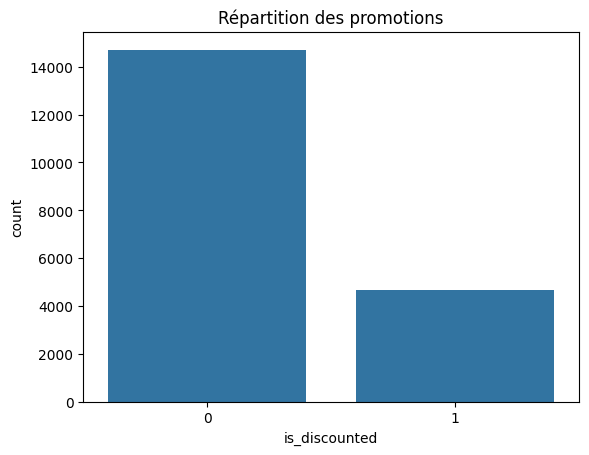

In [35]:
#CountPlot discout
sns.countplot(x="is_discounted", data=df)
plt.title("Répartition des promotions")
plt.show()


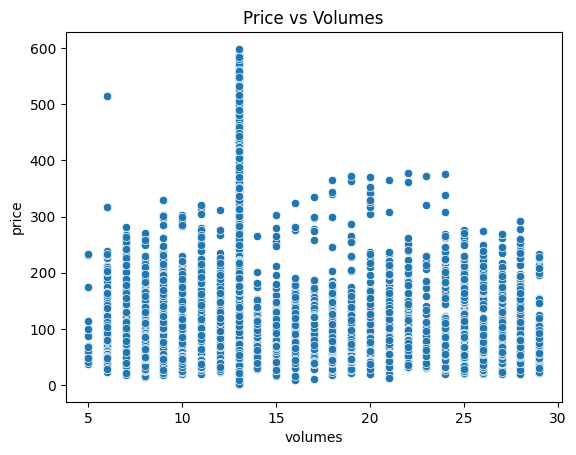

In [36]:
# Scatter pplot : price VS volume
sns.scatterplot(x="volumes", y="price", data=df)
plt.title("Price vs Volumes")
plt.show()


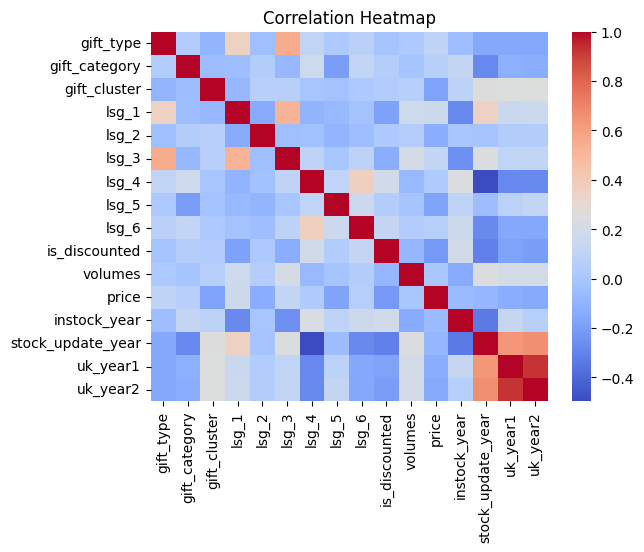

In [37]:
#HeatMap
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
